In [81]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn import set_config

sns.set_theme()
set_config(transform_output="pandas")

# LOADING DATA SET

In [82]:
df = pd.read_csv("./raw data/Titanic-Dataset.csv")

# LOOKING INTO DATA SET

In [83]:
df.shape

(891, 12)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [85]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [86]:
df.duplicated().sum()

0

In [87]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [88]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [89]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [90]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [91]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [92]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [93]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [94]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# VISUALIZING DATA

## Visualizing categorical columns

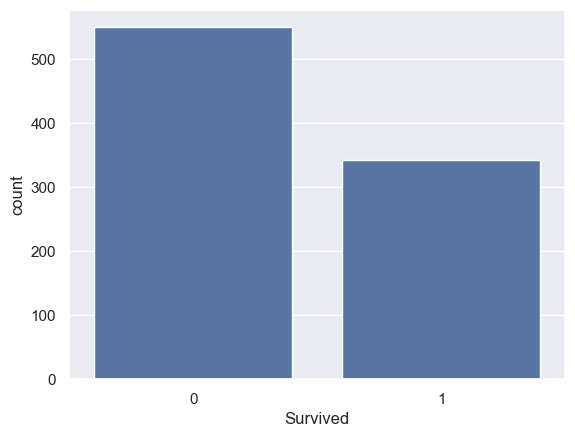

In [121]:
sns.countplot(x='Survived', data=df)
plt.savefig('./plots/CountPlot_Survived')

0 = Not Survived

1 = Survived

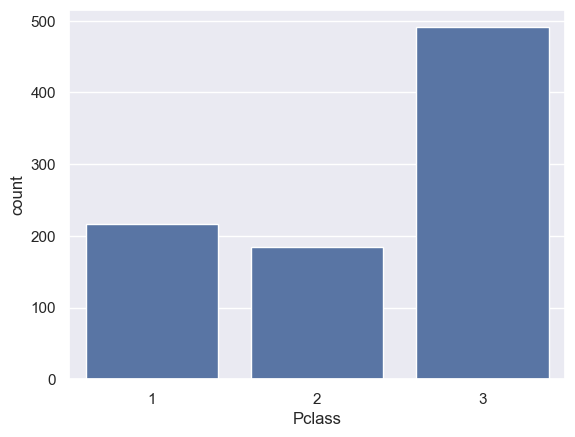

In [122]:
sns.countplot(x='Pclass', data=df)
plt.savefig('./plots/CountPlot_Pclass')

<Axes: xlabel='Sex', ylabel='count'>

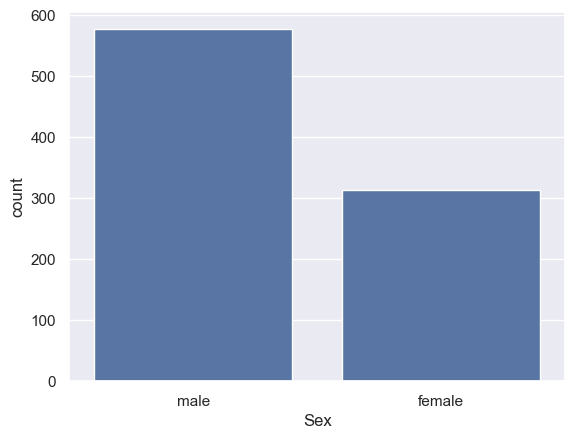

In [97]:
sns.countplot(x='Sex', data=df)

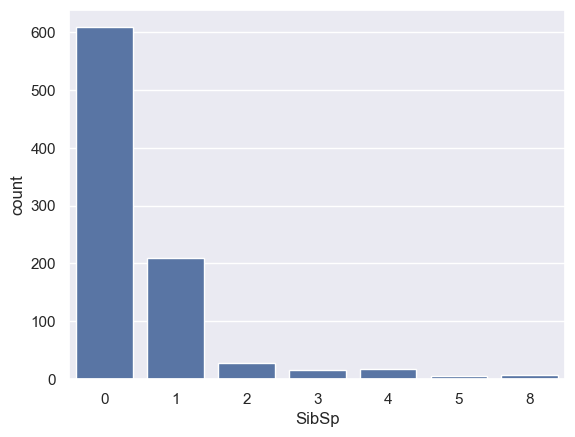

In [123]:
sns.countplot(x='SibSp', data=df)
plt.savefig('./plots/CountPlot_SibSp')

<Axes: xlabel='Parch', ylabel='count'>

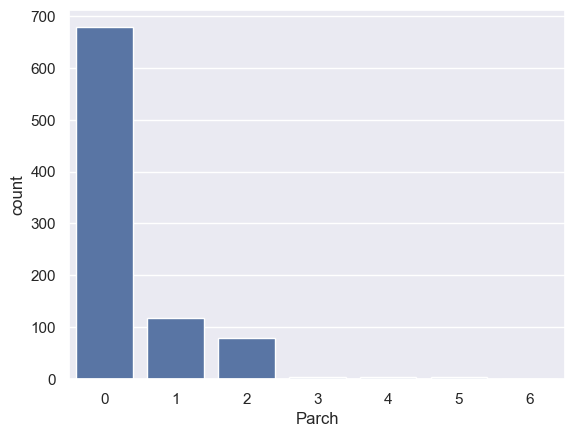

In [99]:
sns.countplot(x='Parch', data=df)

## Visualizing numerical column

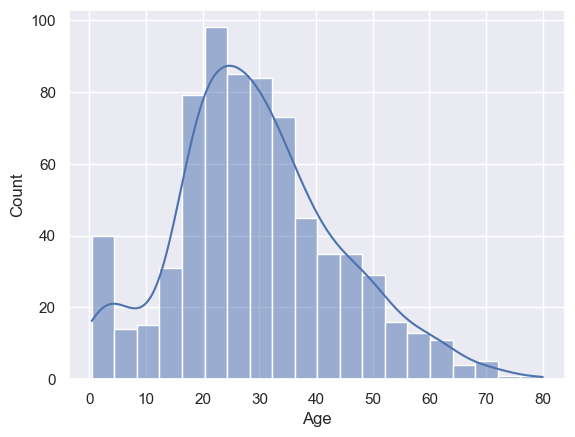

In [124]:
sns.histplot(df['Age'], kde=True)
plt.savefig('./plots/Hist_Age')

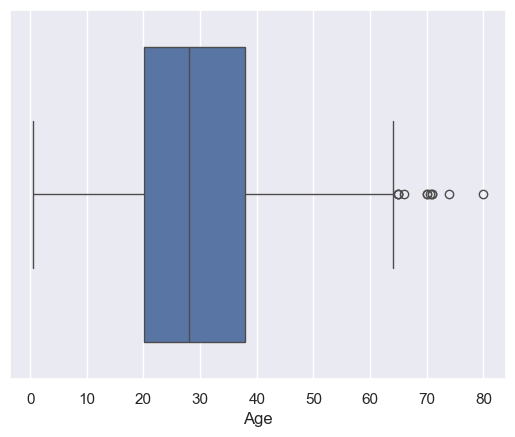

In [125]:
sns.boxplot(x=df['Age'])
plt.savefig('./plots/BoxPlot_Age')

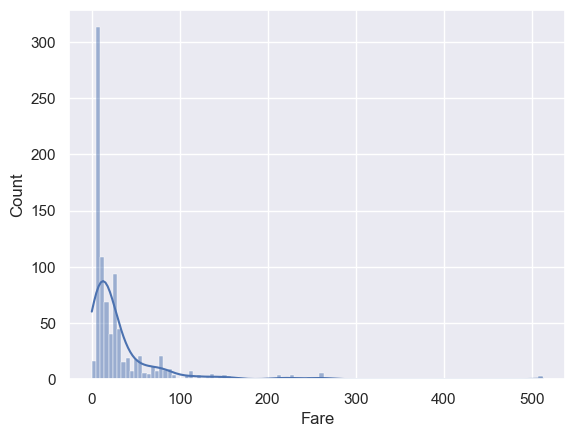

In [126]:
sns.histplot(df['Fare'], kde=True)
plt.savefig('./plots/Hist_Fare')

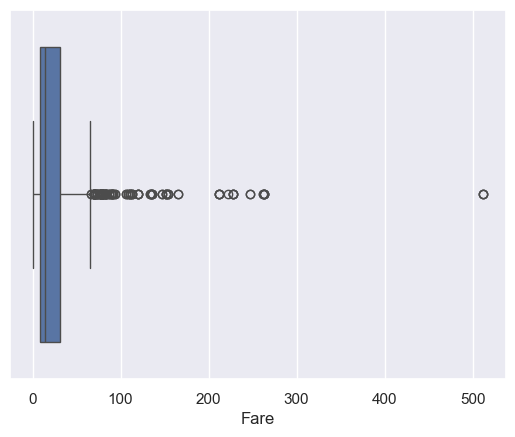

In [127]:
sns.boxplot(x=df['Fare'])
plt.savefig('./plots/BoxPlot_Fare')

## Correlations

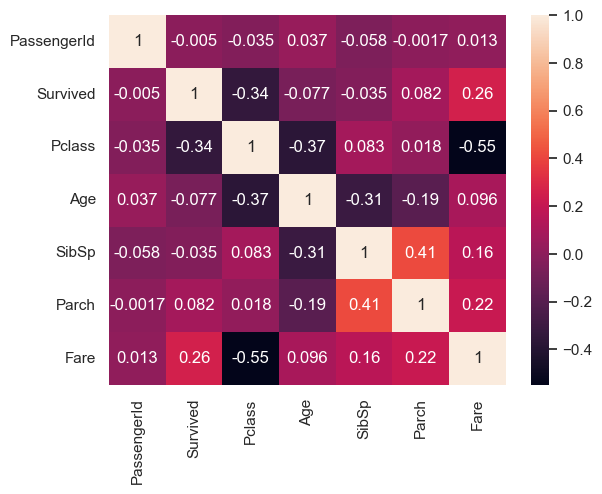

In [128]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.savefig('./plots/Heatmap')

## Age vs Fare

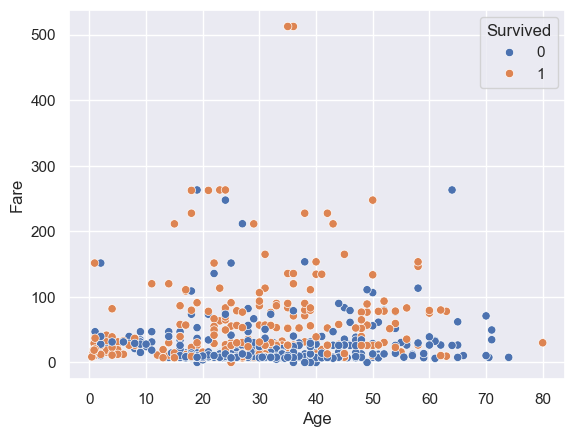

In [129]:
sns.scatterplot(x="Age", y="Fare", data=df, hue='Survived')
plt.savefig('./plots/ScatterPlot_Age_vs_Fare')

## Survived vs Fare

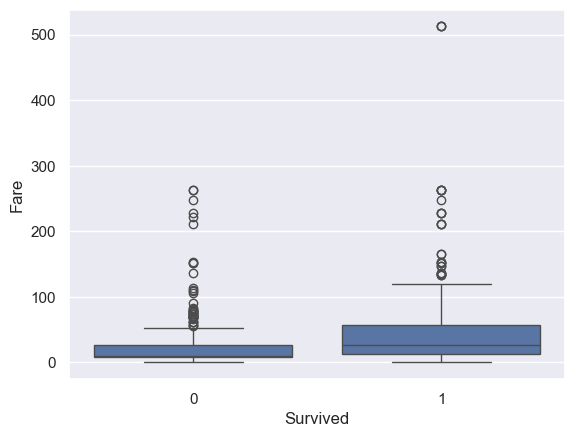

In [130]:
sns.boxplot(x='Survived', y='Fare', data=df)
plt.savefig('./plots/BoxPlot_Survived_vs_Fare')

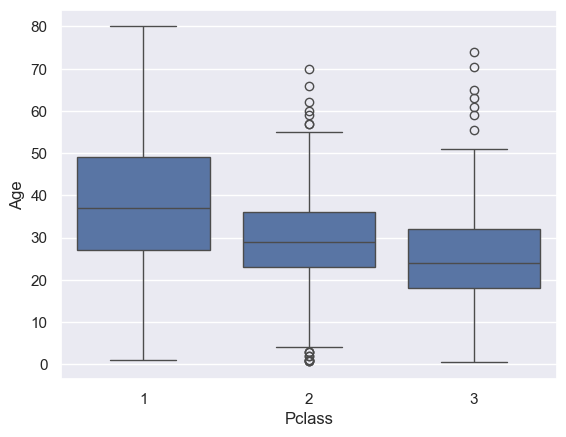

In [131]:
sns.boxplot(x='Pclass', y='Age', data=df)
plt.savefig('./plots/BoxPlot_Pclass_vs_Age')

## Survival by Gender

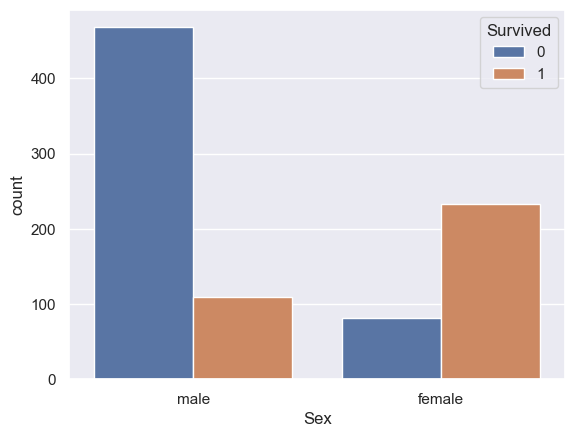

In [135]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.savefig('./plots/BarPlot_Survived_Sex')

## Survival by Pclass

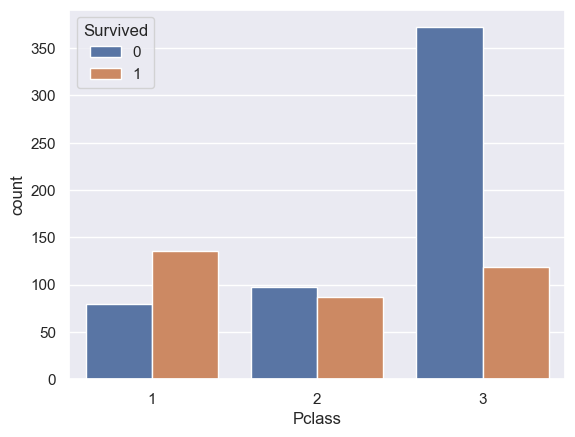

In [136]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.savefig('./plots/Survived_Pclass')

## Visualizing the missing values of the Age column

In [108]:
missing_age_df = df[df['Age'].isna()]
missing_age_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


<Axes: xlabel='Fare', ylabel='Count'>

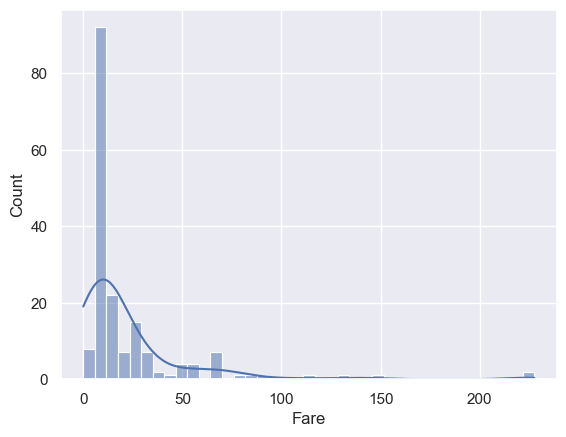

In [109]:
sns.histplot(missing_age_df['Fare'], kde=True)

<Axes: xlabel='Survived', ylabel='count'>

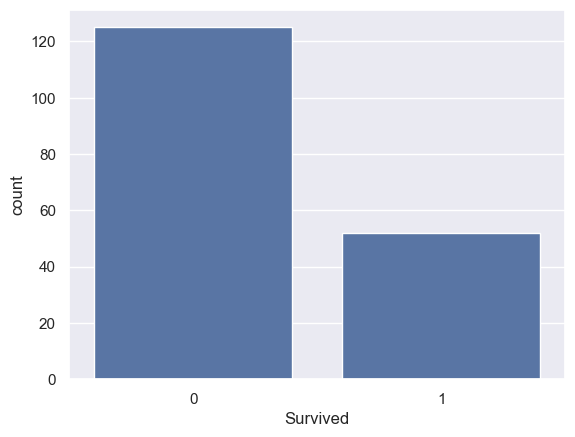

In [110]:
sns.countplot(x=missing_age_df['Survived'], data=df)

<Axes: xlabel='Sex', ylabel='count'>

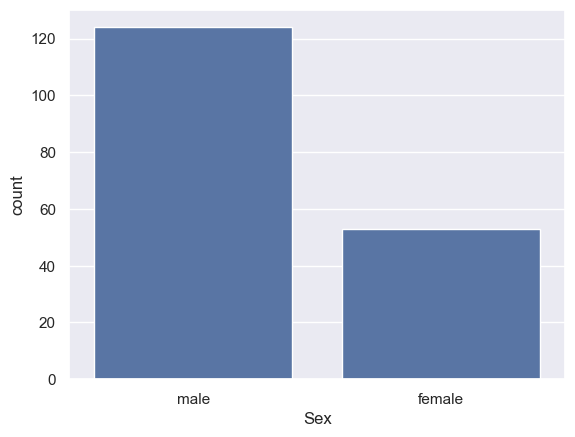

In [111]:
sns.countplot(x=missing_age_df['Sex'])

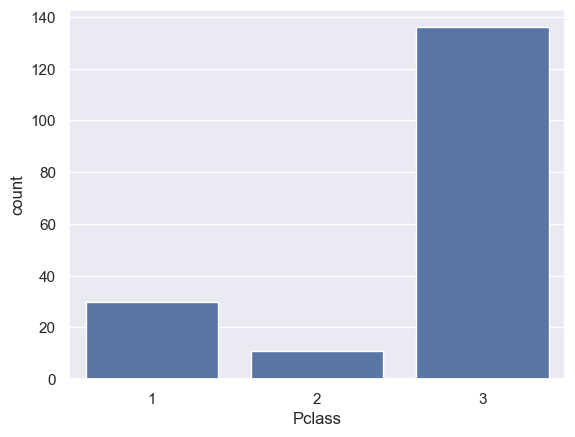

In [132]:
sns.countplot(x=missing_age_df['Pclass'])
plt.savefig('./plots/CountPlot_Pclass_of_missed_age')

# SPLITTING DATA SET

In [113]:
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin'])
y = df["Survived"]

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=93)

# SETTING THE PIPELING

In [115]:
numeric_features = ['Age', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'SibSp', 'Parch']

In [116]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

In [117]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# RUNNING THE PIPELINE

In [118]:
X_train_clean = preprocessor.fit_transform(X_train)
X_test_clean = preprocessor.transform(X_test)

# SAVING THE DATA

In [120]:
X_train_clean.to_csv('./processed data/X_train_clean.csv', index=False)
X_test_clean.to_csv('./processed data/X_test_clean.csv', index=False)
y_train.to_csv('./processed data/y_train.csv', index=False)
y_test.to_csv('./processed data/y_test.csv', index=False)